In [ ]:
%load_ext autoreload
%autoreload 2

from IPython.display import Math, Latex

import pandas as pd, cvxpy as cp, numpy as np, matplotlib as mpl  # type: ignore
import matplotlib.pyplot as plt  # type: ignore

from matplotlib.ticker import FuncFormatter, MultipleLocator  # type: ignore
from matplotlib.patches import FancyArrowPatch, Polygon  # type: ignore
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

from scipy.integrate import quad  # type: ignore
from scipy.spatial import ConvexHull
from scipy.interpolate import interp1d

import importlib, itertools, csv, concurrent.futures
import os, math, sys, json, pickle, shutil, time, functools

from typing import Dict, List, Any, Optional, Literal
from tqdm.notebook import tqdm
import networkx as nx

from Utils import Notebook, tex, gph, sgn, nm, ds
from Simulator import *
# from SimulatorOld import *
from optimization import DisturbedSaturatedPETC as DSPETC
import TrafficModels as tm

cfg = {
    'style': {'color': 'black'},
    'axis': {
        'title_pad': 10,
        'x_label_fontsize': 16,
        'y_label_fontsize': 16,
        'tick_fontsize': 16,
    },
    'legend': {'fontsize': 16}
}

colors_list = plt.get_cmap('tab20').colors
Notebook.setup()

LaTeX has been enabled for text rendering.


### Definição da Planta

In [ ]:
experiment_filename = 'exp-03'

with open(f"experiment-datas/{experiment_filename}.json", encoding='utf-8') as f:
  exp_data = json.load(f)

plant = ds.StateSpace(data=exp_data["plant"], name='plant')
latex_expr = plant.get_latex_equations()
print("Equações que regem a dinâmica da planta:")
tex.display_latex(latex_expr)

Equações que regem a dinâmica da planta:


<IPython.core.display.Latex object>

### Projeto do Controlador e do ETM

In [ ]:
import Simulator
import matplotlib.pyplot as plt

# Parâmetros
EXPERIMENT_FILE = f"experiment-datas/{experiment_filename}.json"

In [ ]:
def run_problem_solving(
    h: float,
    υ: float,
    α: float,
    eps: float = 1e-6,
):
  n_x = plant.nx
  n_u = plant.nu

  Onx = np.zeros((n_x, n_x))

  matrices = plant.evaluate_matrices(None, None, None)
  A = matrices['A']
  B = matrices['B']

  e = nm.get_e(5 * [n_x])

  for i in range(1, len(e)):
    e[i] = cp.Parameter(e[i].shape, value=e[i], name=f"e{i}")

  constraints = []

  Ptil = cp.Variable((n_x, n_x), PSD=True)
  Mtil = cp.Variable((2 * n_x, 2 * n_x), PSD=True)
  Q1til = cp.Variable((n_x, n_x), symmetric=True)
  Q2til = cp.Variable((n_x, n_x))
  Q3til = cp.Variable((n_x, n_x))
  S1til = cp.Variable((n_x, n_x), symmetric=True)
  S2til = cp.Variable((n_x, n_x))
  S3til = cp.Variable((n_x, n_x))
  Ktil = cp.Variable((n_u, n_x))

  Rtil = cp.Variable((n_x, n_x), PSD=True)
  Ξtil = cp.Variable((n_x, n_x), PSD=True)
  Ψtil = cp.Variable((n_x, n_x), PSD=True)

  X = cp.Variable((n_x, n_x))
  Ytil = cp.Variable((2 * n_x, e[1].shape[1]))

  Rcal = cp.bmat([[Rtil, Onx],
                  [Onx, 3. * Rtil]])

  Fscr = e[1].T + υ * e[2].T + υ * e[4].T

  κ1 = cp.bmat([[e[2]], [e[5]]])
  κ2 = cp.bmat([[e[1] - e[2]],
                [e[1] + e[2] - 2. * e[3]]])

  def get_Θ(ω):
    Bscr = A @ X @ e[1] + B @ Ktil @ e[2] + \
        B @ Ktil @ e[5] - X @ e[4]
    Θ1 = (e[1] - e[2]).T @ S1til @ (e[1] - e[2]) + \
        nm.He((e[1] - e[2]).T @ (S2til @ e[2] + S3til @ e[5]))
    Θ2 = nm.He(e[3].T @ (Q2til @ e[2] + Q3til @ e[5]))
    Θ3 = nm.He(e[1].T @ (Q1til @ e[3] + Q2til @ e[2] + Q3til @ e[5]))
    Θ4 = nm.He(e[4].T @ (S1til @ (e[1] - e[2]) + S2til @
               e[2] + S3til @ e[5])) + e[4].T @ Rtil @ e[4]
    return nm.He(e[1].T @ Ptil @ e[4] + Fscr @ Bscr - κ2.T @ Ytil) - e[5].T @ Ξtil @ e[5] - \
        Θ1 - ω * Θ2 - h * e[3].T @ Q1til @ e[3] + \
        (h - ω) * Θ3 + (h - 2.0 * ω) * κ1.T @ Mtil @ κ1 + \
        (h - ω) * Θ4

  def get_Γ():
    Γ1_11 = get_Θ(0)
    Γ1_12 = e[2].T @ X.T
    Γ1_21 = Γ1_12.T
    Γ1_22 = - Ψtil

    Γ1 = cp.bmat([[Γ1_11, Γ1_12],
                  [Γ1_21, Γ1_22]])

    Γ2_11 = get_Θ(h)
    Γ2_12 = Ytil.T
    Γ2_21 = Γ2_12.T
    Γ2_22 = - (1. / h) * Rcal
    Γ2_13 = e[2].T @ X.T
    Γ2_23 = np.zeros((2 * n_x, n_x))
    Γ2_31 = Γ2_13.T
    Γ2_32 = Γ2_23.T
    Γ2_33 = - Ψtil

    Γ2 = cp.bmat([[Γ2_11, Γ2_12, Γ2_13],
                  [Γ2_21, Γ2_22, Γ2_23],
                  [Γ2_31, Γ2_32, Γ2_33]])

    return Γ1, Γ2

  Γ1, Γ2 = get_Γ()
  constraints += [Γ1 << -eps * np.eye(Γ1.shape[0])]
  constraints += [Γ2 << -eps * np.eye(Γ2.shape[0])]

  constraints += [Ξtil >> eps * np.eye(n_x)]
  constraints += [Ψtil >> eps * np.eye(n_x)]

  obj = cp.Minimize(cp.trace(α * Ξtil + (1.0 - α) * Ψtil))
  # obj = cp.Minimize(cp.trace(Ξtil + Ψtil))
  prob = cp.Problem(obj, constraints)

  try:
    prob.solve(solver=cp.MOSEK, verbose=False, ignore_dpp=True)
    if prob.status in ["infeasible", "unbounded"]:
      return None
    Xinv = np.linalg.inv(X.value)
    Ξ = Xinv.T @ Ξtil.value @ Xinv
    Ψ = np.linalg.inv(Ψtil.value)
    K = Ktil.value @ Xinv

    return {
        'etm': {'Ξ': Ξ, 'Ψ': Ψ},
        'controller': {'K': K},
        'status': prob.status,
        'obj_value': prob.value
    }

  except cp.error.SolverError:
    return None

In [ ]:
A = plant.evaluate_matrices(None, None, None)['A']
B = plant.evaluate_matrices(None, None, None)['B']

h = exp_data["design_params"]['h']
iet_max = exp_data["design_params"]['iet_max']
υ = 1e-1
α = 0.5
result = run_problem_solving(h=h, υ=υ, α=α)

Ξ = result['etm']['Ξ']
Ψ = result['etm']['Ψ']
K = result['controller']['K']

# Verificação dos resultados
if result:
  print("=== Síntese Concluída com Sucesso ===")
  print(f"Status do Solver: {result['status']}")
  print(f"Valor da Função de Custo: {result['obj_value']:.4f}")

  print("\nGanho K:")
  print(result['controller']['K'])

  print("\nMatriz Xi (ETM):")
  print(result['etm']['Ξ'])

  print("\nMatriz Psi (ETM):")
  print(result['etm']['Ψ'])

else:
  print("!!! O problema restou Inviável para estes parâmetros !!!")

=== Síntese Concluída com Sucesso ===
Status do Solver: optimal
Valor da Função de Custo: 0.0029

Ganho K:
[[-12.22329015 -13.39014745]]

Matriz Xi (ETM):
[[21995238.3478488  24094943.41056697]
 [24094943.41056697 26395090.13450921]]

Matriz Psi (ETM):
[[19495.16510823 17983.1318399 ]
 [17983.1318399  20219.71704309]]


In [ ]:
x0 = [0.3, 0.8]
y, t, u, events = closed_loop_setm(x0, EXPERIMENT_FILE, result)

Média: 0.01 s
Economia: 63.00%


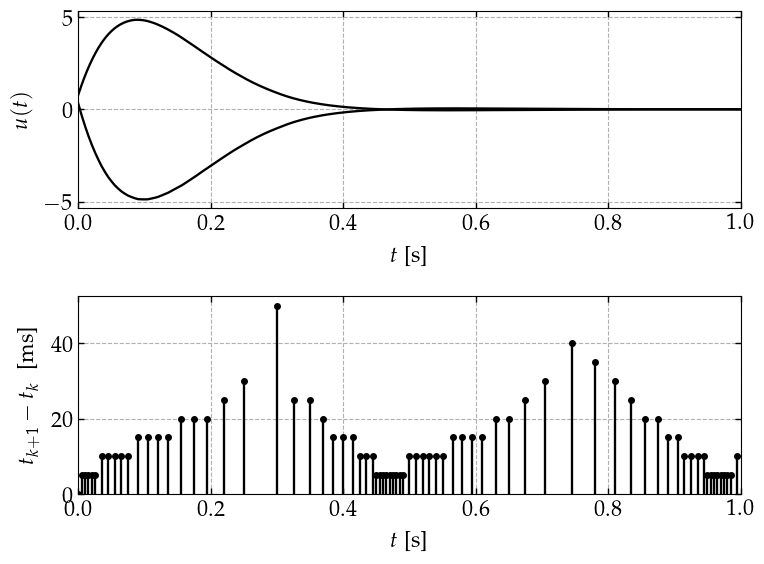

In [ ]:
mosaic = [['y'], ['iet']]
fig, axs = plt.subplot_mosaic(mosaic, figsize=(8, 6))

inter_event_times = nm.compute_deltas(events)
ks_iet = np.round(np.array(inter_event_times) / h).astype(int).tolist()

simulation_time = exp_data["duration"]
sampling_time = exp_data["design_params"]['h']
n_samples = simulation_time / sampling_time
saving = 100.0 * (1.0 - len(events) / (n_samples))
print("Média:", f"{(sum(inter_event_times) / len(inter_event_times)):.2f} s")
print("Economia:", f"{saving:.2f}%")

for i in range(plant.nu):
  gph.plot(
      axs['y'], t, y, xlabel='$t$', x_unit='s', x_use_prefixes=True,
      ylabel=r'$u(t)$', y_pad=(0.05, 0.05),
      cfg={**cfg, 'style': {'color': "black", "linestyle": ["-"], }},)

gph.stem(
    axs['iet'], events, inter_event_times,
    reuse_previous=False, y_pad=(0.0, 0.05), x_use_prefixes=True,
    xlabel='$t$', x_unit='s', x_range=(0.0, t[-1]),
    ylabel='$t_{k+1} - t_k\\;$', y_unit='s', y_use_prefixes=True,
    cfg={**cfg, 'limits': {'x_min': 0, 'x_max': t[-1]}})

plt.tight_layout(pad=2.)